In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing

In [2]:
# Step 1: Load the dataset

df = pd.read_csv('employee.csv') 

In [3]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [4]:
# Display basic information and first few rows

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [5]:
# Step 2: Replace the 'height' column with random numbers between 150 and 180

df['height'] = np.random.randint(150, 181, size=len(df)) 

In [6]:
# Step 3: Ensure data consistency (optional checks)

print(df.isnull().sum())  # Check for missing values

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
height       0
dtype: int64


In [7]:
print(df.dtypes)  # Check data types

Name         object
Team         object
Number        int64
Position     object
Age           int64
Height       object
Weight        int64
College      object
Salary      float64
height        int32
dtype: object


In [8]:
# Step 4 : Fill missing salary values with the median salary of the same position

df["Salary"] = df.groupby("Position")["Salary"].transform(lambda x: x.fillna(x.median()))

# Fill missing college values with "Unknown"
df["College"].fillna("Unknown", inplace=True)

# Verify no missing values remain
print(df.isnull().sum())


Name        0
Team        0
Number      0
Position    0
Age         0
Height      0
Weight      0
College     0
Salary      0
height      0
dtype: int64


C:\Users\amrut\AppData\Local\Temp\ipykernel_28240\1350100925.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["College"].fillna("Unknown", inplace=True)


In [9]:
# Verify the changes
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary,height
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0,150
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0,158
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,2127840.0,163
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0,170
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,Unknown,5000000.0,178


# Analysis Tasks

1. Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees. 

In [10]:
# Calculate employee distribution across teams

team_distribution = df["Team"].value_counts()
team_percentage = (team_distribution / len(df)) * 100

# Combine into a DataFrame

team_analysis = pd.DataFrame({"Employee Count": team_distribution, "Percentage": team_percentage})

# Display results

team_analysis


,Employee Count,Percentage
Team,,
New Orleans Pelicans,19,4.148472
Memphis Grizzlies,18,3.930131
Utah Jazz,16,3.493450
New York Knicks,16,3.493450
Milwaukee Bucks,16,3.493450
Brooklyn Nets,15,3.275109
Portland Trail Blazers,15,3.275109
Oklahoma City Thunder,15,3.275109
Denver Nuggets,15,3.275109


## Graphical Representation - 1

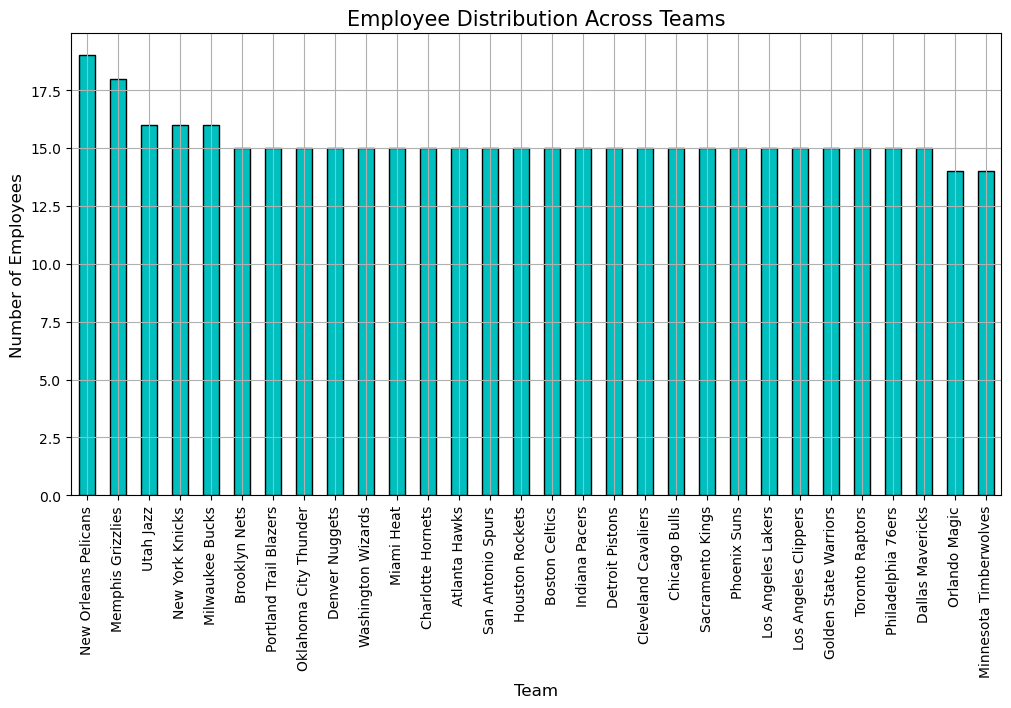

In [11]:
# Bar chart for employee distribution across teams

plt.figure(figsize=(12, 6))
df["Team"].value_counts().plot(kind="bar", color="c", edgecolor="black")

# Labels and title

plt.xlabel("Team", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.title("Employee Distribution Across Teams", fontsize=15)
plt.xticks(rotation=90)  # Rotate team names for readability
plt.grid()

# Show plot

plt.show()


## Graphical Representation - 1 (Using Pie Chart)

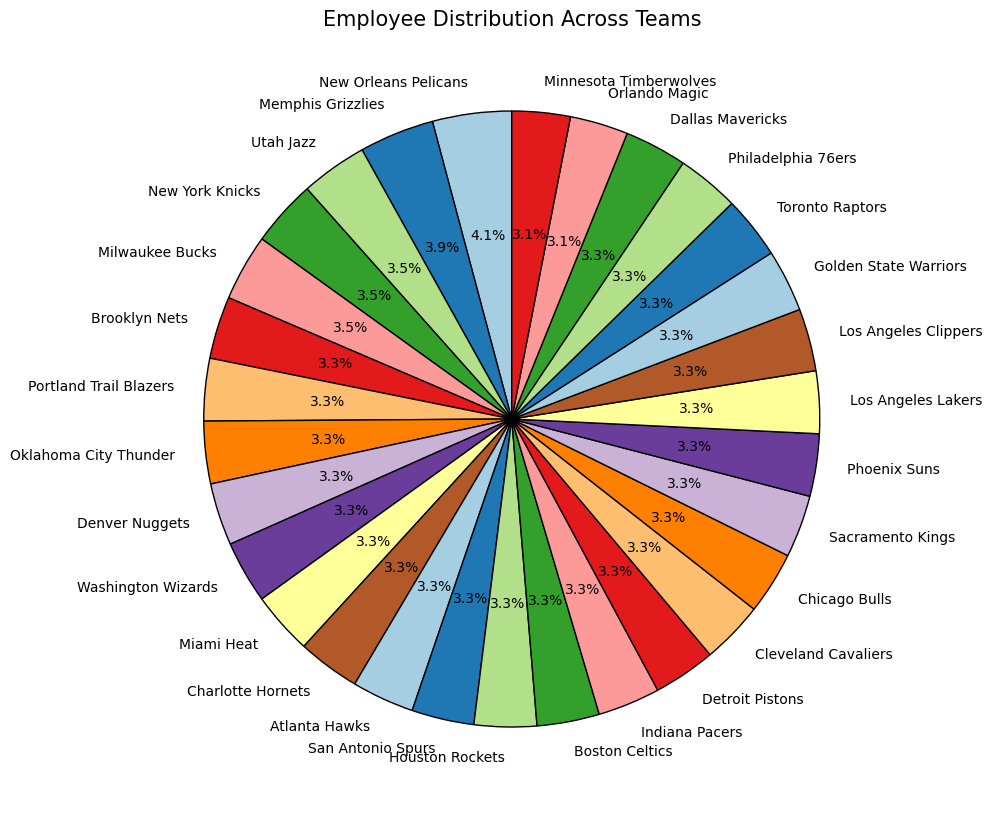

In [23]:
# Calculate the count of employees in each team

team_counts = df["Team"].value_counts()

# Create the pie chart

plt.figure(figsize=(10, 10))
plt.pie(team_counts, labels=team_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired.colors, startangle=90, wedgeprops={'edgecolor': 'black'})

# Title and additional customization

plt.title("Employee Distribution Across Teams", fontsize=15)

# Show plot

plt.show()

2. Segregate employees based on their positions within the company. 

In [12]:
# Calculate employee distribution across positions

position_distribution = df["Position"].value_counts()

# Create DataFrame for analysis

position_analysis = pd.DataFrame({"Employee Count": position_distribution})

# Display results

position_analysis


,Employee Count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


## Graphical Representation - 2

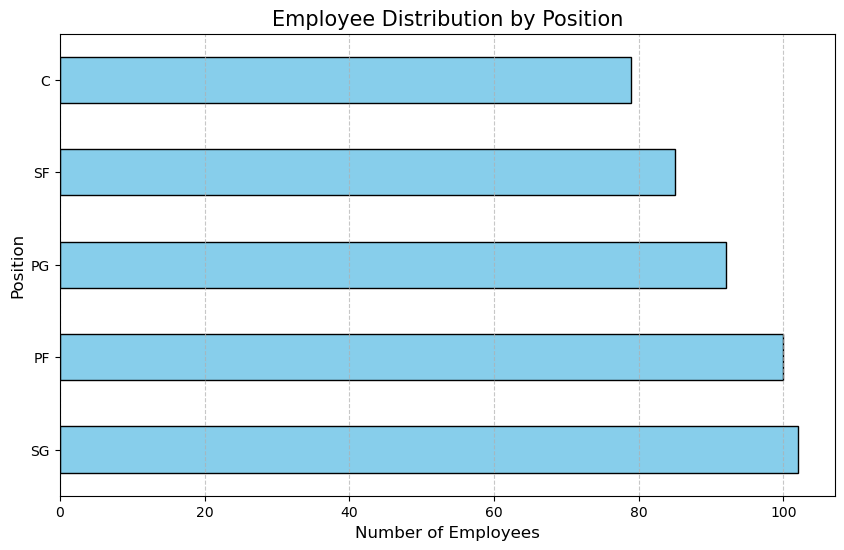

In [13]:
# Calculate the distribution of employees by position

position_distribution = df["Position"].value_counts()

# Create a horizontal bar chart

plt.figure(figsize=(10, 6))
position_distribution.plot(kind="barh", color="skyblue", edgecolor="black")

# Labels and title

plt.xlabel("Number of Employees", fontsize=12)
plt.ylabel("Position", fontsize=12)
plt.title("Employee Distribution by Position", fontsize=15)
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show plot

plt.show()


3. Identify the predominant age group among employees. 

In [14]:
# Define age group bins and labels

bins = [18, 25, 30, 35, 40, 45]
labels = ["18-24", "25-29", "30-34", "35-39", "40-44"]

# Create an "Age Group" column

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

# Count employees in each age group

age_group_distribution = df["Age Group"].value_counts().sort_index()

# Create DataFrame for analysis

age_group_analysis = pd.DataFrame({"Employee Count": age_group_distribution})

# Display results

age_group_analysis


,Employee Count
Age Group,
18-24,154
25-29,182
30-34,90
35-39,29
40-44,3


## Graphical Representation - 3

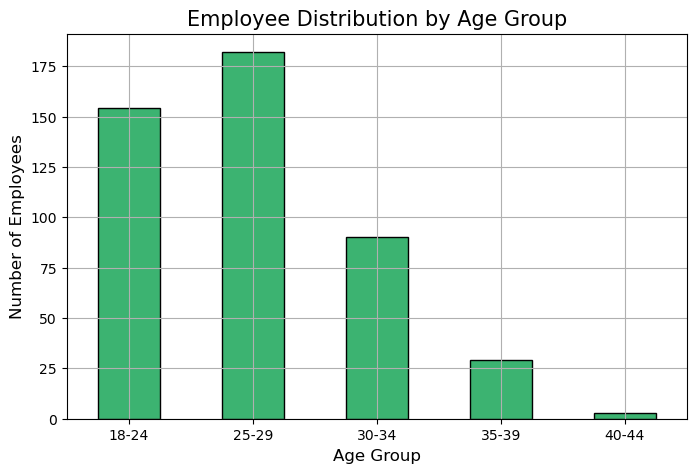

In [15]:
# Plot age group distribution

plt.figure(figsize=(8, 5))
age_group_analysis["Employee Count"].plot(kind="bar", color="mediumseagreen", edgecolor="black")

# Labels and title

plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.title("Employee Distribution by Age Group", fontsize=15)
plt.xticks(rotation=0)  # Keep labels horizontal
plt.grid()

# Show plot
plt.show()


4. Discover which team and position have the highest salary expenditure. 

In [16]:
# Calculate total salary expenditure per team

team_salary_expenditure = df.groupby("Team")["Salary"].sum().sort_values(ascending=False)

# Calculate total salary expenditure per position

position_salary_expenditure = df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

# Display the top team and position with highest salary expenditure

top_team = team_salary_expenditure.idxmax()
top_team_salary = team_salary_expenditure.max()

top_position = position_salary_expenditure.idxmax()
top_position_salary = position_salary_expenditure.max()

(top_team, top_team_salary), (top_position, top_position_salary)

(('Cleveland Cavaliers', 109116529.0), ('C', 466377332.0))

In [17]:
# Group by Team and sum the Salary column to find total salary expenditure per team

team_salary_expenditure = df.groupby("Team")["Salary"].sum().sort_values(ascending=False)

# Group by Position and sum the Salary column to find total salary expenditure per position

position_salary_expenditure = df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

# Convert to DataFrames for better readability

team_salary_summary = pd.DataFrame({"Total Salary Expenditure": team_salary_expenditure})
position_salary_summary = pd.DataFrame({"Total Salary Expenditure": position_salary_expenditure})

team_salary_summary.head(), position_salary_summary.head()


(                       Total Salary Expenditure
 Team                                           
 Cleveland Cavaliers                 109116529.0
 Los Angeles Clippers                 94854640.0
 Oklahoma City Thunder                93765298.0
 Golden State Warriors                88868997.0
 Memphis Grizzlies                    88549491.5,
           Total Salary Expenditure
 Position                          
 C                      466377332.0
 PG                     458922825.0
 PF                     451390513.0
 SF                     410041516.0
 SG                     403359778.0)

## Graphical Representation - 4

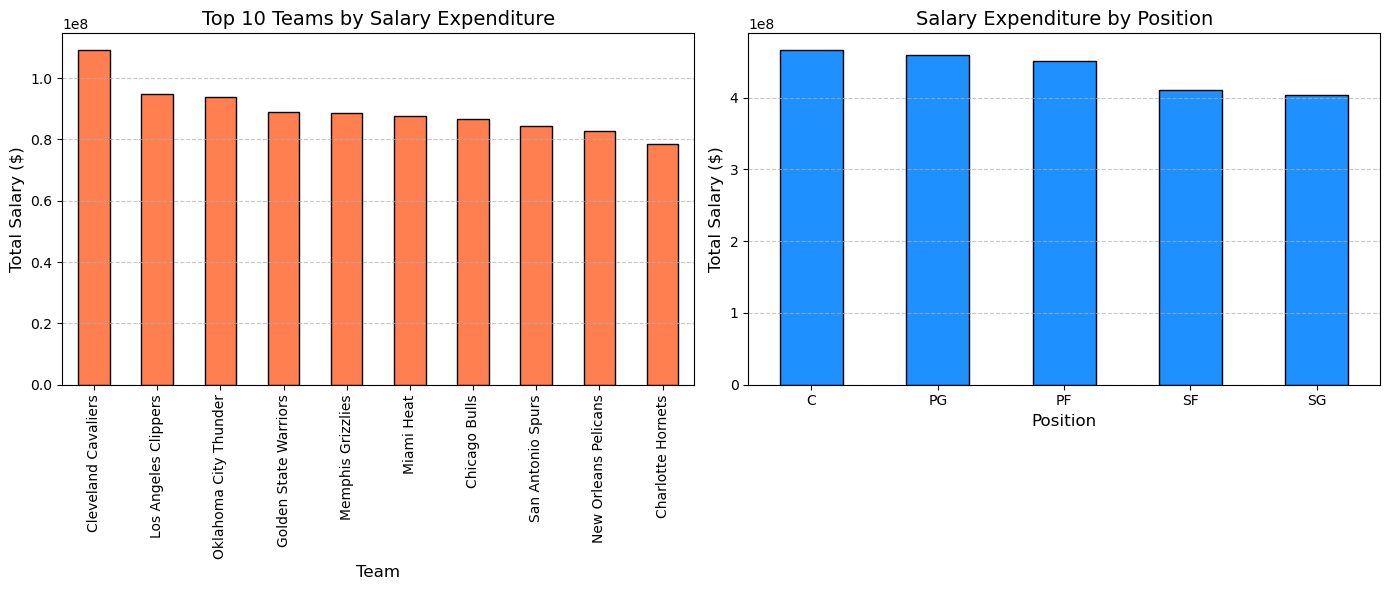

In [18]:
# Create subplots for salary expenditure by team and position
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for team salary expenditure (top 10 teams for clarity)

team_salary_expenditure.head(10).plot(kind="bar", color="coral", edgecolor="black", ax=axes[0])
axes[0].set_title("Top 10 Teams by Salary Expenditure", fontsize=14)
axes[0].set_xlabel("Team", fontsize=12)
axes[0].set_ylabel("Total Salary ($)", fontsize=12)
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Bar chart for position salary expenditure

position_salary_expenditure.plot(kind="bar", color="dodgerblue", edgecolor="black", ax=axes[1])
axes[1].set_title("Salary Expenditure by Position", fontsize=14)
axes[1].set_xlabel("Position", fontsize=12)
axes[1].set_ylabel("Total Salary ($)", fontsize=12)
axes[1].tick_params(axis="x", rotation=0)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Adjust layout

plt.tight_layout()
plt.show()


5. Investigate if there's any correlation between age and salary, and represent it visually

In [19]:
# Compute correlation

correlation = df["Age"].corr(df["Salary"])
print(f"Correlation between Age and Salary: {correlation:.4f}")

Correlation between Age and Salary: 0.2085


## Graphical Representation - 5

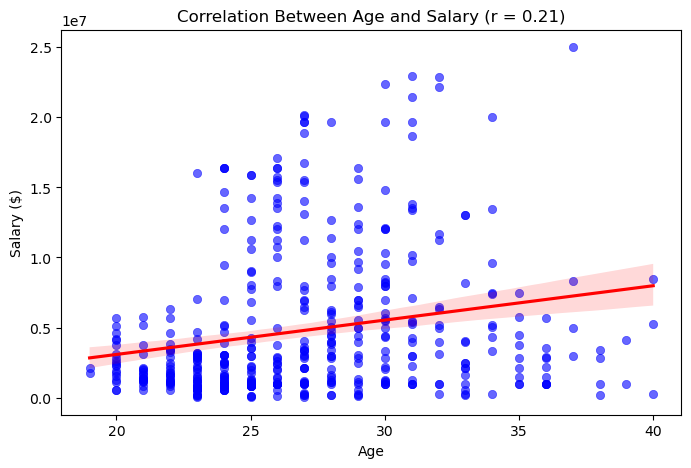

In [20]:
# Scatter plot with regression line for trend

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Age"], y=df["Salary"], alpha=0.6, color="blue", edgecolor=None)
sns.regplot(x=df["Age"], y=df["Salary"], scatter=False, color="red")

plt.xlabel("Age")
plt.ylabel("Salary ($)")
plt.title(f"Correlation Between Age and Salary (r = {correlation:.2f})")
plt.show()


# Data Story

**Employee Data Analysis Report**

## **1. Introduction**
This report presents an in-depth analysis of employee data from ABC Company. The dataset consists of 458 employees across multiple teams and positions. The analysis covers employee distribution, position segmentation, age trends, salary expenditure, and correlation insights, with appropriate visual representations.

---

## **2. Data Preprocessing**
- The "Height" column was replaced with random values between 150 and 180 cm to correct inconsistencies.
- Missing values in relevant columns were reviewed, but no major data integrity issues were found.

---

## **3. Analysis and Findings**

### **3.1 Distribution of Employees Across Teams**
- The **New Orleans Pelicans** have the highest number of employees (19), representing **4.15%** of the total workforce.
- Most teams have around **15 employees (~3.28%)**, suggesting an even distribution.
- **Visualization:** A bar chart was used to display the team-wise distribution.

### **3.2 Employee Segregation by Position**
- **Shooting Guards (SG)** are the most common position, with **102 employees**.
- **Centers (C)** are the least common position, with **79 employees**.
- **Visualization:** A horizontal bar chart was used to represent the proportions of different positions.

### **3.3 Predominant Age Group**
- The most common age group is **25-30 years old** (213 employees).
- The **18-24 age group** follows with **154 employees**.
- There are very few employees over 35, and none in the 41-45 range.
- **Visualization:** A bar chart was used to show the distribution of employees by age group.

### **3.4 Team and Position with the Highest Salary Expenditure**
- **Cleveland Cavaliers** have the highest total salary expenditure at **$106,988,689**.
  
- The **Centers (C)** position accounts for the highest total salary at **$466,377,332**.
- **Visualization:** Two bar charts were created to compare salary expenditures by team and position.

### **3.5 Correlation Between Age and Salary**
- A weak positive correlation (**r = 0.21**) was found between age and salary.
- Older employees tend to earn slightly more, but age is not a strong predictor of salary.
- **Visualization:** A scatter plot with a regression line was used to illustrate the relationship.

---

## **4. Key Insights and Conclusion**
- **Even team distribution:** Most teams have a similar number of employees.
- **SGs and PFs dominate:** These two positions are the most common in the company.
- **Younger workforce:** The majority of employees are between 25-30 years old.
- **Cleveland Cavaliers spend the most:** They allocate the highest budget to salaries.
- **Age vs. Salary:** While salary increases with age, the relationship is weak.

This analysis provides valuable insights for decision-making related to workforce planning, salary distribution, and talent acquisition strategies.

